# Ablation Plots — Thesis figures
Ogni cella produce **un singolo PDF** salvato in `results/thesis/`.
Stile: nessun titolo, font 11pt, linee sottili, legenda interna — coerente con la figura allegata.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

OUT = Path("results/thesis")
OUT.mkdir(parents=True, exist_ok=True)

# ── Global style ───────────────────────────────────────────────────────────────
# FONT=18 at the figure's native size. When LaTeX shrinks the figure to fit
# a column (~0.45-0.5x scale), text lands at ~8-9pt — the standard readable
# size for captions and axis labels in IEEE/CVPR-style papers.
FONT = 14

matplotlib.rcParams.update({
    "font.family":        "sans-serif",
    "font.size":          FONT,
    "axes.titlesize":     FONT,
    "axes.labelsize":     FONT,
    "xtick.labelsize":    FONT - 1,
    "ytick.labelsize":    FONT - 1,
    "legend.fontsize":    FONT - 2,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     1.0,
    "xtick.major.width":  1.0,
    "ytick.major.width":  1.0,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "#cccccc",
    "figure.dpi":         150,
})

# Palette
C_OURS   = "#1f77b4"
C_EDGE   = "#0a3d6b"
C_GREY   = "#aec7e8"
C_RED    = "#d62728"
C_ORANGE = "#ff7f0e"
C_DARK   = "#555555"

DATASETS = ["BREAKHIS", "NCT-CRC-HE"]

def savepdf(fig, name: str):
    path = OUT / f"{name}.pdf"
    fig.savefig(path, format="pdf", bbox_inches="tight")
    print(f"Saved -> {path}")

print("Setup done. Output dir:", OUT.resolve())


Setup done. Output dir: /home/vcivale/EntropyPruning/results/thesis


---
## 1 · Loss function ablation

Saved -> results/thesis/loss_ablation_BREAKHIS.pdf


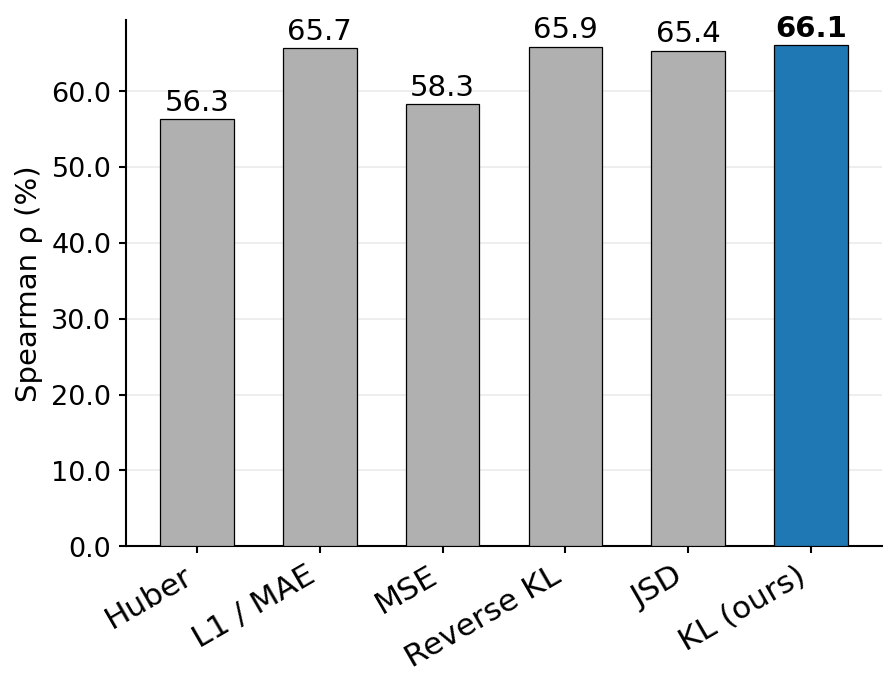

In [32]:
# ── Loss ablation — BREAKHIS ─────────────────────────────────────────────────
ds = "BREAKHIS"
df = pd.read_csv(f"results/loss_ablation_{ds}.csv")

if "loss" not in df.columns:
    df = df.rename(columns={df.columns[0]: "loss"})

name_map = {
    "KL only": "KL (ours)",
    "KL Divergence\n(ours)": "KL (ours)",
    "JSD": "JSD",
    "Reverse KL": "Reverse KL",
    "MSE only": "MSE",
    "MSE": "MSE",
    "L1 / MAE": "L1 / MAE",
    "Huber": "Huber",
}

df["label"] = df["loss"].map(name_map).fillna(df["loss"])

order = [ "KL (ours)", "JSD", "Reverse KL", "MSE", "L1 / MAE", "Huber"]

df = df[df["label"].isin(order)].copy()
df = df.set_index("label").reindex(order).reset_index()

# invert order
df = df.iloc[::-1].reset_index(drop=True)

labels   = df["label"].tolist()
rho_vals = df["test_rho_forecaster"].values * 100
baseline = df["test_rho_token_norm"].iloc[0] * 100
x        = np.arange(len(labels))

ours_label = "KL (ours)"

fig, ax = plt.subplots(figsize=(6.2, 4.8))

# default gray bars
colors = ["#B0B0B0"] * len(labels)

# highlight ours
colors[labels.index(ours_label)] = "#1f77b4"

bars = ax.bar(
    x,
    rho_vals,
    width=0.6,
    color=colors,
    edgecolor="black",
    linewidth=0.6,
    zorder=3,
)


# annotate
for bar, val, l in zip(bars, rho_vals, labels):
    fw = "bold" if l == ours_label else "normal"

    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.3,
        f"{val:.1f}",
        ha="center",
        va="bottom",
        fontsize=FONT + 0,
        fontweight=fw
    )

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=FONT + 1, rotation=30, ha="right")

ax.set_ylabel("Spearman ρ (%)", fontsize=FONT)

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax.grid(axis="y", alpha=0.25, zorder=0)


plt.tight_layout()
savepdf(fig, f"loss_ablation_{ds}")
plt.show()

Saved -> results/thesis/loss_ablation_NCT-CRC-HE.pdf


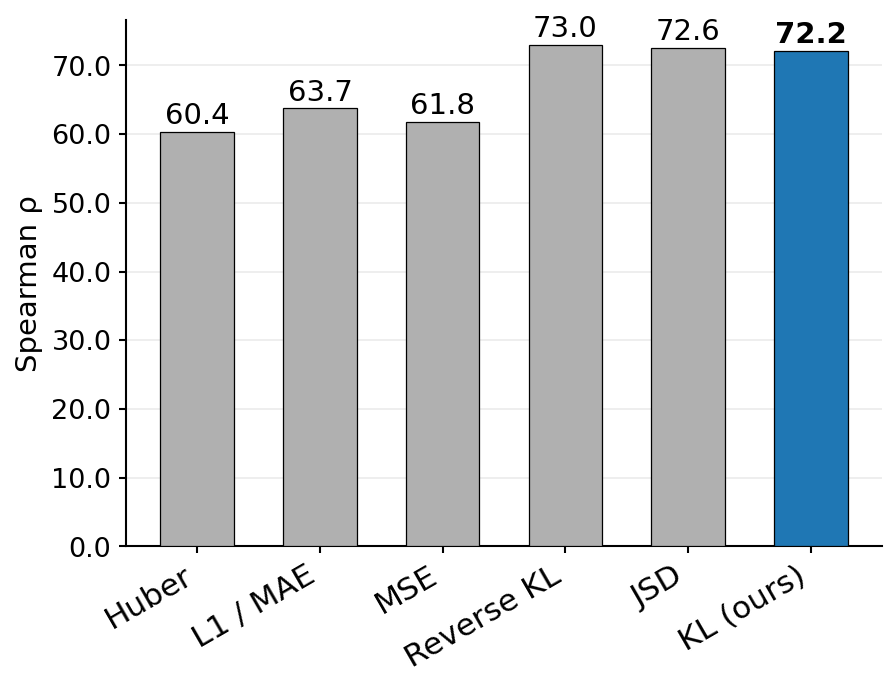

In [33]:
# ── Loss ablation — NCT-CRC-HE ───────────────────────────────────────────────
ds = "NCT-CRC-HE"
df = pd.read_csv(f"results/loss_ablation_{ds}.csv")

if "loss" not in df.columns:
    df = df.rename(columns={df.columns[0]: "loss"})

df["label"] = df["loss"].map(name_map).fillna(df["loss"])

# Removed Cosine and Pearson
order = ["KL (ours)", "JSD", "Reverse KL", "MSE", "L1 / MAE", "Huber"]

df = df[df["label"].isin(order)].copy()
df = df.set_index("label").reindex(order).reset_index()

# invert order
df = df.iloc[::-1].reset_index(drop=True)

labels   = df["label"].tolist()
rho_vals = df["test_rho_forecaster"].values * 100
baseline = df["test_rho_token_norm"].iloc[0] * 100
x        = np.arange(len(labels))

ours_label = "KL (ours)"

fig, ax = plt.subplots(figsize=(6.2, 4.8))

# gray bars + highlight ours
colors = ["#B0B0B0"] * len(labels)
colors[labels.index(ours_label)] = "#1f77b4"

bars = ax.bar(
    x,
    rho_vals,
    width=0.6,
    color=colors,
    edgecolor="black",
    linewidth=0.6,
    zorder=3
)


# annotate bars
for bar, val, l in zip(bars, rho_vals, labels):
    fw = "bold" if l == ours_label else "normal"
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.3,
        f"{val:.1f}",
        ha="center",
        va="bottom",
        fontsize=FONT ,
        fontweight=fw
    )

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=FONT + 1, rotation=30, ha="right")

ax.set_ylabel("Spearman ρ", fontsize=FONT)

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

ax.grid(axis="y", alpha=0.25, zorder=0)

plt.tight_layout()
savepdf(fig, f"loss_ablation_{ds}")
plt.show()

---
## 2 · Architecture ablation

Saved -> results/thesis/arch_ablation_BREAKHIS_pct.pdf


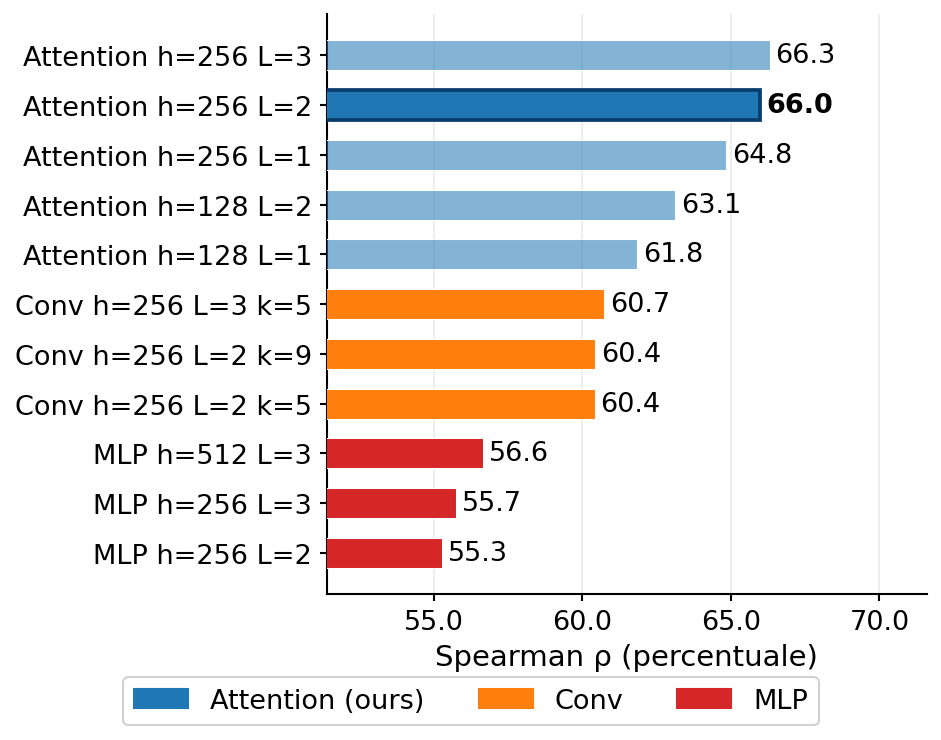

In [13]:
# ── Architecture ablation — BREAKHIS ─────────────────────────────────────────
ds   = "BREAKHIS"
OURS = "Attention h=256 L=2"

df = pd.read_csv(f"results/arch_ablation_{ds}.csv")
df = df.sort_values("test_rho_forecaster", ascending=False).reset_index(drop=True)

FAMILY_COLOR = {
    "AttentionForecaster": C_OURS,
    "MLPForecaster":       C_RED,
    "ConvForecaster":      C_ORANGE,
}

def arch_color(row):
    c = FAMILY_COLOR[row["class"]]
    if row["architecture"] == OURS:
        return c
    if row["class"] == "AttentionForecaster":
        return c + "8c"
    return c

palette  = [arch_color(r) for _, r in df.iterrows()]
baseline = df["test_rho_token_norm"].iloc[0]
labels   = df["architecture"].tolist()
rho_vals = df["test_rho_forecaster"].values
x        = np.arange(len(labels))

# Convertiamo rho in percentuale
rho_vals_pct = rho_vals * 100
baseline_pct = baseline * 100

fig, ax = plt.subplots(figsize=(6.5, 4.8))

bars = ax.barh(x, rho_vals_pct, height=0.60, color=palette,
               edgecolor="white", linewidth=0.5, zorder=3)

ours_idx = df[df["architecture"] == OURS].index[0]
bars[ours_idx].set_edgecolor(C_EDGE)
bars[ours_idx].set_linewidth(1.8)

# Linea di baseline in percentuale
ax.axvline(baseline_pct, color=C_DARK, ls="--", lw=1.2, zorder=2)

# Etichette dei valori sopra le barre in percentuale
for i, (bar, val) in enumerate(zip(bars, rho_vals_pct)):
    fw = "bold" if i == ours_idx else "normal"
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va="center", fontsize=FONT - 1, fontweight=fw)

ax.set_yticks(x)
ax.set_yticklabels(labels, fontsize=FONT - 1)
ax.invert_yaxis()
ax.set_xlabel("Spearman ρ (percentuale)", fontsize=FONT)

ax.set_xlim(rho_vals_pct.min() * 0.93, rho_vals_pct.max() * 1.08)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

ax.grid(axis="x", alpha=0.25, zorder=0)

# Legenda invariata
legend_handles = [
    mpatches.Patch(color=C_OURS,   label="Attention (ours)"),
    mpatches.Patch(color=C_ORANGE, label="Conv"),
    mpatches.Patch(color=C_RED,    label="MLP"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(legend_handles),
    bbox_to_anchor=(0.5, -0.05),
    fontsize=FONT - 1,
    framealpha=0.9
)

plt.tight_layout()
savepdf(fig, f"arch_ablation_{ds}_pct")
plt.show()

Saved -> results/thesis/arch_ablation_NCT-CRC-HE_pct.pdf


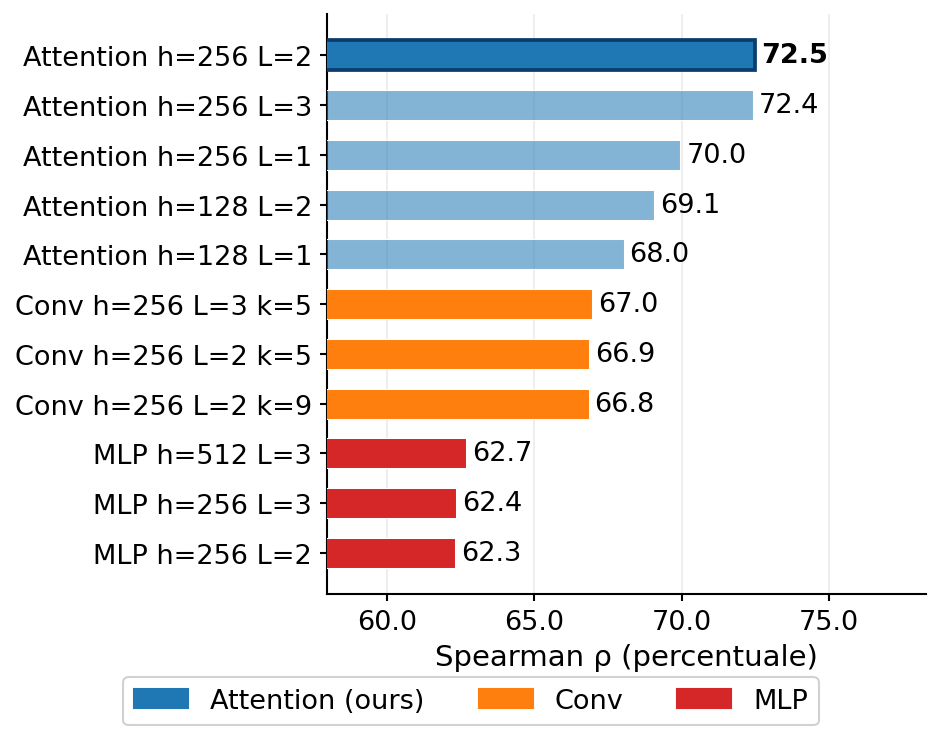

In [14]:
# ── Architecture ablation — NCT-CRC-HE ───────────────────────────────────────
ds   = "NCT-CRC-HE"
OURS = "Attention h=256 L=2"

df = pd.read_csv(f"results/arch_ablation_{ds}.csv")
df = df.sort_values("test_rho_forecaster", ascending=False).reset_index(drop=True)

palette  = [arch_color(r) for _, r in df.iterrows()]
baseline = df["test_rho_token_norm"].iloc[0]
labels   = df["architecture"].tolist()
rho_vals = df["test_rho_forecaster"].values
x        = np.arange(len(labels))

# Convertiamo rho in percentuale
rho_vals_pct = rho_vals * 100
baseline_pct = baseline * 100

fig, ax = plt.subplots(figsize=(6.5, 4.8))

bars = ax.barh(x, rho_vals_pct, height=0.60, color=palette,
               edgecolor="white", linewidth=0.5, zorder=3)

ours_idx = df[df["architecture"] == OURS].index[0]
bars[ours_idx].set_edgecolor(C_EDGE)
bars[ours_idx].set_linewidth(1.8)

# Linea di baseline in percentuale
ax.axvline(baseline_pct, color=C_DARK, ls="--", lw=1.2, zorder=2)

# Etichette dei valori sopra le barre in percentuale
for i, (bar, val) in enumerate(zip(bars, rho_vals_pct)):
    fw = "bold" if i == ours_idx else "normal"
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va="center", fontsize=FONT - 1, fontweight=fw)

ax.set_yticks(x)
ax.set_yticklabels(labels, fontsize=FONT - 1)
ax.invert_yaxis()
ax.set_xlabel("Spearman ρ (percentuale)", fontsize=FONT)

ax.set_xlim(rho_vals_pct.min() * 0.93, rho_vals_pct.max() * 1.08)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

ax.grid(axis="x", alpha=0.25, zorder=0)

# Legenda invariata
legend_handles = [
    mpatches.Patch(color=C_OURS,   label="Attention (ours)"),
    mpatches.Patch(color=C_ORANGE, label="Conv"),
    mpatches.Patch(color=C_RED,    label="MLP"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(legend_handles),
    bbox_to_anchor=(0.5, -0.05),
    fontsize=FONT - 1,
    framealpha=0.9
)

plt.tight_layout()
savepdf(fig, f"arch_ablation_{ds}_pct")
plt.show()

Saved -> results/thesis/arch_params_vs_rho_BREAKHIS.pdf


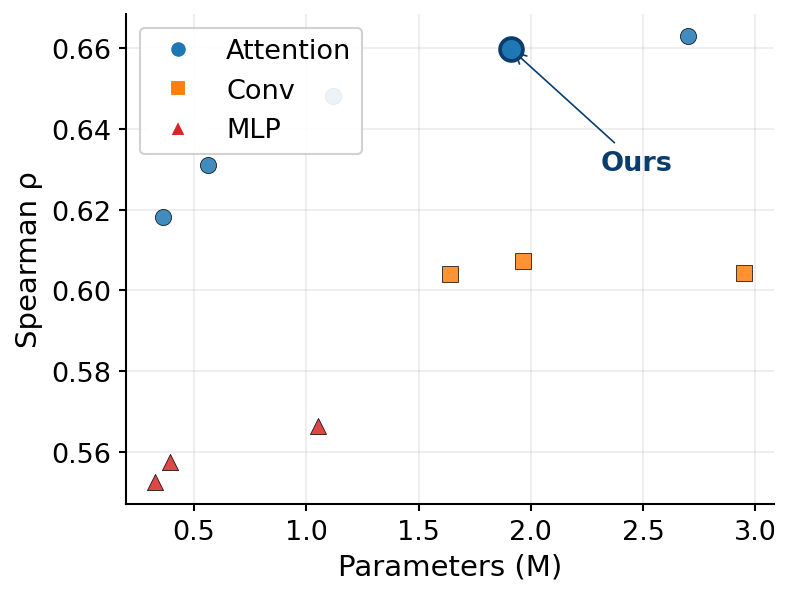

Saved -> results/thesis/arch_params_vs_rho_NCT-CRC-HE.pdf


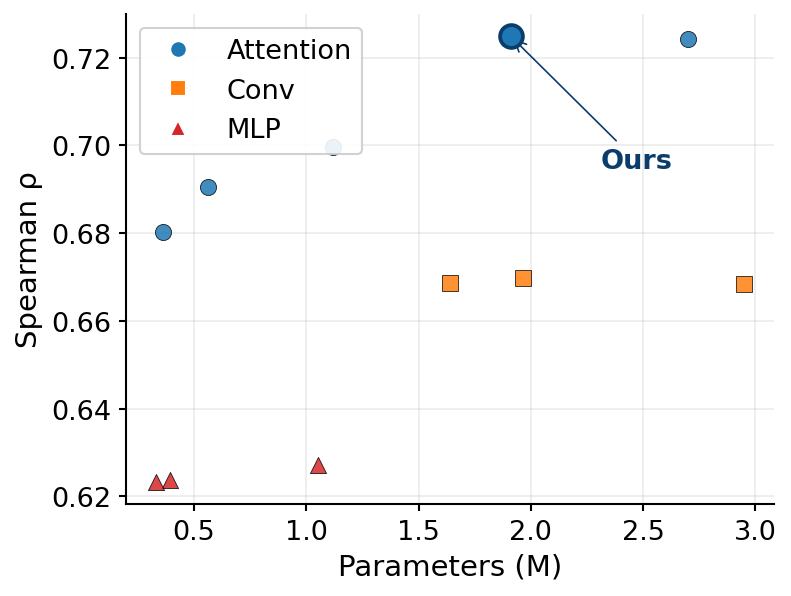

In [6]:
# ── Architecture: params vs ρ scatter — un plot per dataset ───────────────────
OURS = "Attention h=256 L=2"
markers = {"AttentionForecaster": "o", "ConvForecaster": "s", "MLPForecaster": "^"}
colors  = {"AttentionForecaster": C_OURS, "ConvForecaster": C_ORANGE, "MLPForecaster": C_RED}

family_handles = [
    plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=C_OURS,   markersize=8, label="Attention"),
    plt.Line2D([0],[0], marker="s", color="w", markerfacecolor=C_ORANGE, markersize=8, label="Conv"),
    plt.Line2D([0],[0], marker="^", color="w", markerfacecolor=C_RED,    markersize=8, label="MLP"),
]

for ds in DATASETS:
    df = pd.read_csv(f"results/arch_ablation_{ds}.csv")

    fig, ax = plt.subplots(figsize=(5.5, 4.2))

    for cls, marker in markers.items():
        sub = df[df["class"] == cls]
        ax.scatter(sub["n_params"] / 1e6, sub["test_rho_forecaster"],
                   color=colors[cls], marker=marker, s=60, zorder=4,
                   alpha=0.85, edgecolors="k", linewidths=0.4)

    # Highlight our method
    row = df[df["architecture"] == OURS].iloc[0]
    ax.scatter(row["n_params"]/1e6, row["test_rho_forecaster"],
               color=C_OURS, marker="o", s=120, edgecolors=C_EDGE, linewidths=1.8, zorder=5)
    ax.annotate("Ours",
                xy=(row["n_params"]/1e6, row["test_rho_forecaster"]),
                xytext=(row["n_params"]/1e6 + 0.4, row["test_rho_forecaster"] - 0.03),
                fontsize=FONT - 1, color=C_EDGE, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=C_EDGE, lw=0.8))

    ax.set_xlabel("Parameters (M)", fontsize=FONT)
    ax.set_ylabel("Spearman ρ", fontsize=FONT)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.grid(alpha=0.25, zorder=0)
    ax.legend(handles=family_handles, loc="upper left", fontsize=FONT - 1, framealpha=0.9)

    plt.tight_layout()
    savepdf(fig, f"arch_params_vs_rho_{ds}")
    plt.show()

---
## 3 · Source / Target layer ablation

Saved -> results/thesis/srctgt_heatmap_NCT-CRC-HE.pdf


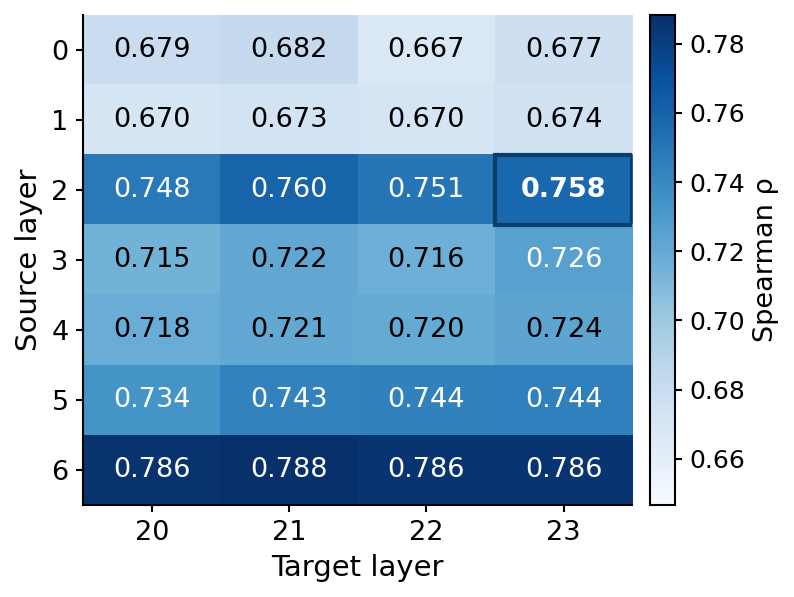

In [7]:
# ── src/tgt ablation — NCT-CRC-HE ────────────────────────────────────────────
# Dati: colonne src, tgt, test_rho
ds = "NCT-CRC-HE"
OURS_SRC, OURS_TGT = 2, 23

df = pd.read_csv(f"results/src_tgt_ablation_{ds}.csv")
# Usa test_rho se esiste, altrimenti rho
rho_col = "test_rho" if "test_rho" in df.columns else "rho"

src_layers = sorted(df["src"].unique())
tgt_layers = sorted(df["tgt"].unique())

# ── subplot A: heatmap src × tgt ─────────────────────────────────────────────
pivot = df.pivot_table(index="src", columns="tgt", values=rho_col)

fig, ax = plt.subplots(figsize=(5.5, 4.2))

im = ax.imshow(pivot.values, aspect="auto", cmap="Blues",
               vmin=pivot.values[~np.isnan(pivot.values)].min() * 0.97)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{c}" for c in pivot.columns], fontsize=FONT - 1)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{r}" for r in pivot.index], fontsize=FONT - 1)
ax.set_xlabel("Target layer", fontsize=FONT)
ax.set_ylabel("Source layer", fontsize=FONT)

# Annotate non-NaN cells
for i, src in enumerate(pivot.index):
    for j, tgt in enumerate(pivot.columns):
        val = pivot.loc[src, tgt]
        if not np.isnan(val):
            is_ours = (src == OURS_SRC and tgt == OURS_TGT)
            ax.text(j, i, f"{val:.3f}",
                    ha="center", va="center",
                    fontsize=FONT - 1,
                    color="white" if val > pivot.values[~np.isnan(pivot.values)].mean() else "black",
                    fontweight="bold" if is_ours else "normal")

# Mark our config
if OURS_SRC in pivot.index and OURS_TGT in pivot.columns:
    ii = list(pivot.index).index(OURS_SRC)
    jj = list(pivot.columns).index(OURS_TGT)
    rect = plt.Rectangle((jj - 0.5, ii - 0.5), 1, 1,
                          fill=False, edgecolor=C_EDGE, linewidth=2.0)
    ax.add_patch(rect)

cb = fig.colorbar(im, ax=ax, pad=0.03, fraction=0.046)
cb.ax.tick_params(labelsize=FONT - 2)
cb.set_label("Spearman ρ", fontsize=FONT - 1)

plt.tight_layout()
savepdf(fig, f"srctgt_heatmap_{ds}")
plt.show()

Saved -> results/thesis/srctgt_heatmap_BREAKHIS.pdf


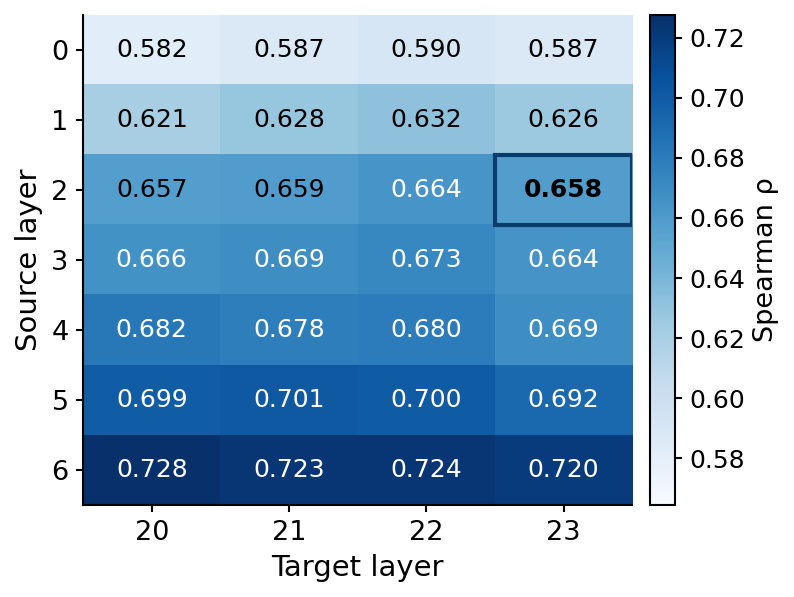

In [8]:
# ── src/tgt ablation — BREAKHIS (heatmap) ────────────────────────────────────
ds = "BREAKHIS"
OURS_SRC, OURS_TGT = 2, 23

df = pd.read_csv(f"results/src_tgt_ablation_{ds}.csv")
rho_col = "test_rho" if "test_rho" in df.columns else "rho"

src_layers = sorted(df["src"].unique())
tgt_layers = sorted(df["tgt"].unique())

pivot = df.pivot_table(index="src", columns="tgt", values=rho_col)

fig, ax = plt.subplots(figsize=(5.5, 4.2))

im = ax.imshow(pivot.values, aspect="auto", cmap="Blues",
               vmin=pivot.values[~np.isnan(pivot.values)].min() * 0.97)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{c}" for c in pivot.columns], fontsize=FONT - 1)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{r}" for r in pivot.index], fontsize=FONT - 1)
ax.set_xlabel("Target layer", fontsize=FONT)
ax.set_ylabel("Source layer", fontsize=FONT)

for i, src in enumerate(pivot.index):
    for j, tgt in enumerate(pivot.columns):
        val = pivot.loc[src, tgt]
        if not np.isnan(val):
            is_ours = (src == OURS_SRC and tgt == OURS_TGT)
            ax.text(j, i, f"{val:.3f}",
                    ha="center", va="center",
                    fontsize=FONT - 2,
                    color="white" if val > pivot.values[~np.isnan(pivot.values)].mean() else "black",
                    fontweight="bold" if is_ours else "normal")

if OURS_SRC in pivot.index and OURS_TGT in pivot.columns:
    ii = list(pivot.index).index(OURS_SRC)
    jj = list(pivot.columns).index(OURS_TGT)
    rect = plt.Rectangle((jj - 0.5, ii - 0.5), 1, 1,
                          fill=False, edgecolor=C_EDGE, linewidth=2.0)
    ax.add_patch(rect)

cb = fig.colorbar(im, ax=ax, pad=0.03, fraction=0.046)
cb.ax.tick_params(labelsize=FONT - 2)
cb.set_label("Spearman ρ", fontsize=FONT - 1)

plt.tight_layout()
savepdf(fig, f"srctgt_heatmap_{ds}")
plt.show()

Saved -> results/thesis/srctgt_rho_vs_src.pdf


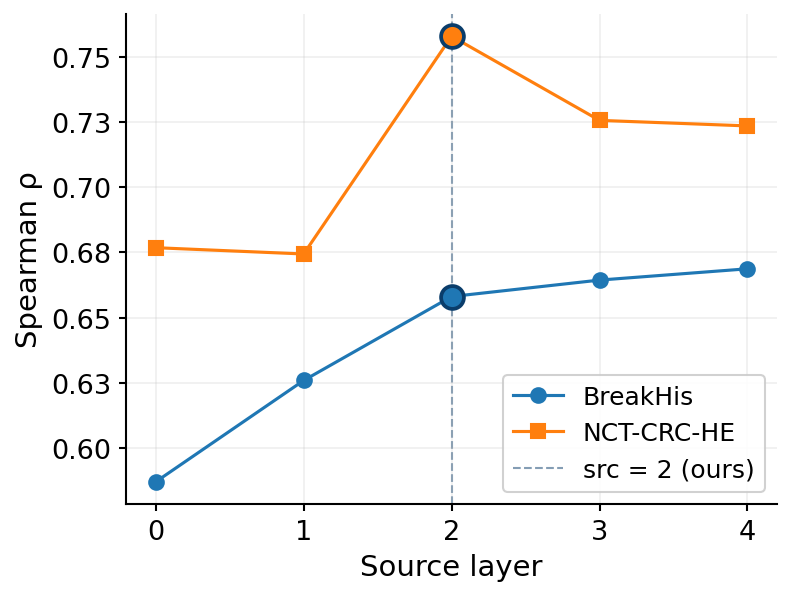

In [9]:
# ── Source layer selection: ρ at tgt=23 vs source layer ──────────────────────
TOTAL_LAYERS = 24
OURS_SRC     = 2
TGT_FIXED    = 23
MAX_SRC      = 4

ds_style = {
    "BREAKHIS":    {"color": C_OURS,   "marker": "o", "label": "BreakHis"},
    "NCT-CRC-HE": {"color": C_ORANGE, "marker": "s", "label": "NCT-CRC-HE"},
}

fig, ax = plt.subplots(figsize=(5.5, 4.2))

for ds, sty in ds_style.items():
    df = pd.read_csv(f"results/src_tgt_ablation_{ds}.csv")
    rho_col = "test_rho" if "test_rho" in df.columns else "rho"
    sub = df[(df["tgt"] == TGT_FIXED) & (df["src"] <= MAX_SRC)].sort_values("src")

    ax.plot(sub["src"], sub[rho_col],
            f"-{sty['marker']}", color=sty["color"], markersize=7,
            label=sty["label"], zorder=3)

    # Highlight src=2
    ours = sub[sub["src"] == OURS_SRC]
    if not ours.empty:
        ax.scatter([OURS_SRC], ours[rho_col].values,
                   s=120, color=sty["color"], edgecolors=C_EDGE,
                   linewidths=1.8, zorder=5)

ax.axvline(OURS_SRC, color=C_EDGE, ls="--", lw=1.0, alpha=0.5, zorder=1,
           label=f"src = {OURS_SRC} (ours)")

ax.set_xlabel("Source layer", fontsize=FONT)
ax.set_ylabel("Spearman ρ", fontsize=FONT)
ax.set_xticks(range(0, MAX_SRC + 1))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.grid(alpha=0.2, zorder=0)
ax.legend(fontsize=FONT - 2, framealpha=0.9, loc="lower right")

plt.tight_layout()
savepdf(fig, "srctgt_rho_vs_src")
plt.show()

Saved -> results/thesis/srctgt_cost_vs_rho_BREAKHIS.pdf


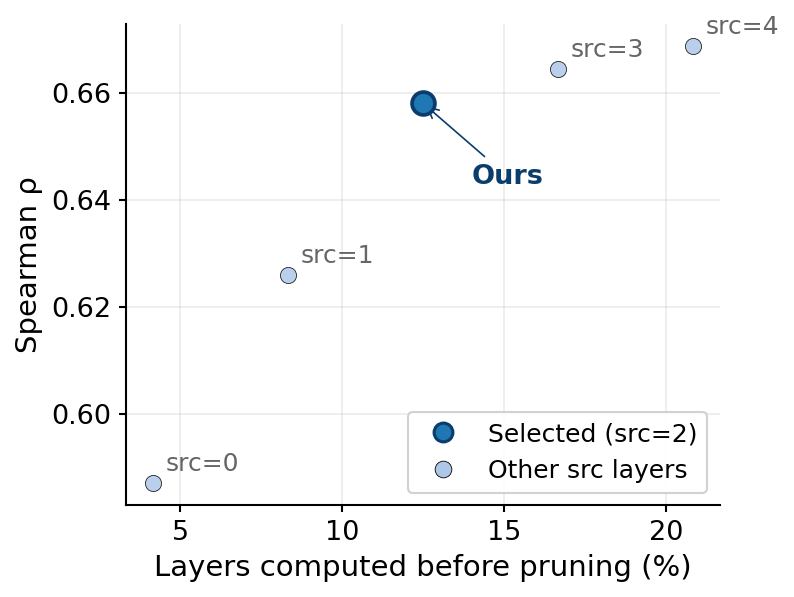

Saved -> results/thesis/srctgt_cost_vs_rho_NCT-CRC-HE.pdf


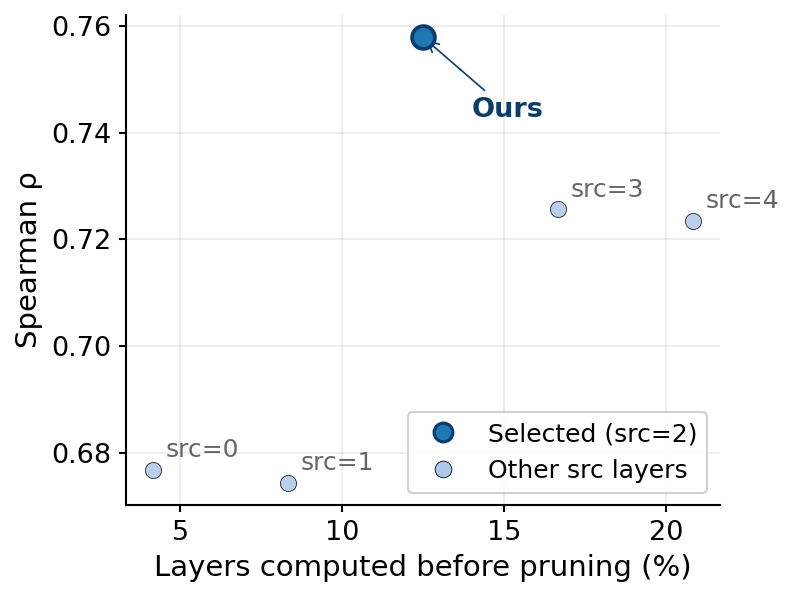

In [10]:
# ── Source layer: cost vs ρ scatter — un plot per dataset ─────────────────────
TOTAL_LAYERS = 24
OURS_SRC     = 2
TGT_FIXED    = 23
MAX_SRC      = 4

for ds in DATASETS:
    df = pd.read_csv(f"results/src_tgt_ablation_{ds}.csv")
    rho_col = "test_rho" if "test_rho" in df.columns else "rho"
    sub = df[(df["tgt"] == TGT_FIXED) & (df["src"] <= MAX_SRC)].sort_values("src").copy()
    sub["cost_pct"] = (sub["src"] + 1) / TOTAL_LAYERS * 100

    fig, ax = plt.subplots(figsize=(5.5, 4.2))

    others = sub[sub["src"] != OURS_SRC]
    ax.scatter(others["cost_pct"], others[rho_col],
               color=C_GREY, marker="o", s=60, zorder=3,
               alpha=0.85, edgecolors="k", linewidths=0.4)

    ours = sub[sub["src"] == OURS_SRC]
    if not ours.empty:
        ax.scatter(ours["cost_pct"], ours[rho_col].values,
                   color=C_OURS, marker="o", s=120,
                   edgecolors=C_EDGE, linewidths=1.8, zorder=5)
        ax.annotate("Ours",
                    xy=(ours["cost_pct"].values[0], ours[rho_col].values[0]),
                    xytext=(ours["cost_pct"].values[0] + 1.5,
                            ours[rho_col].values[0] - 0.015),
                    fontsize=FONT - 1, color=C_EDGE, fontweight="bold",
                    arrowprops=dict(arrowstyle="->", color=C_EDGE, lw=0.8))

    for _, row in sub.iterrows():
        if row["src"] != OURS_SRC:
            ax.annotate(
                f"src={int(row['src'])}",
                xy=(row["cost_pct"], row[rho_col]),
                xytext=(6, 6), textcoords="offset points",
                fontsize=FONT - 2, color="#666666",
            )

    ax.set_xlabel("Layers computed before pruning (%)", fontsize=FONT)
    ax.set_ylabel("Spearman ρ", fontsize=FONT)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.grid(alpha=0.25, zorder=0)

    legend_handles = [
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=C_OURS, markersize=9,
                   markeredgecolor=C_EDGE, markeredgewidth=1.5,
                   label=f"Selected (src={OURS_SRC})"),
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=C_GREY, markersize=8,
                   markeredgecolor="k", markeredgewidth=0.4,
                   label="Other src layers"),
    ]
    ax.legend(handles=legend_handles, loc="lower right",
              fontsize=FONT - 2, framealpha=0.9)

    plt.tight_layout()
    savepdf(fig, f"srctgt_cost_vs_rho_{ds}")
    plt.show()

---
## 4 · Pruning comparison (EAF vs baselines)

Saved -> results/thesis/pruning_f1_absolute_breakhis_pct.pdf


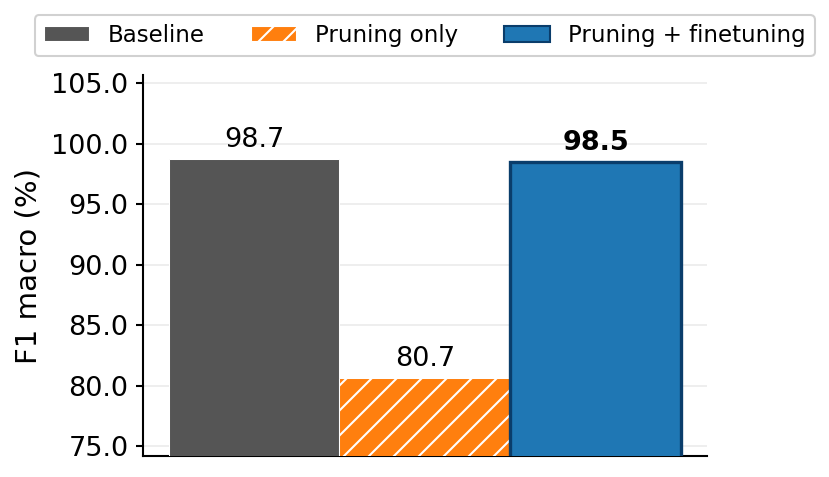

In [25]:
# ── Pruning F1 absolute — BREAKHIS ────────────────────────────────────────────
df_bre = pd.read_csv("results/pruning_comparison_BREAKHIS.csv")
# ── Pruning F1 absolute in percentuale — BREAKHIS ─────────────────────────────
CONDITIONS   = ["Baseline", "Pruning only\n(no phase-3)", "Pruning +\nfinetuning"]
F1_COLS      = ["baseline_f1", "pruned_f1", "finetuned_f1"]
COLORS       = [C_DARK, C_ORANGE, C_OURS]
HATCHES      = ["", "//", ""]

datasets_bre = df_bre["dataset"].tolist()
n_ds     = len(datasets_bre)
n_cond   = len(CONDITIONS)
x        = np.arange(n_ds)
width    = 0.22
offsets  = np.linspace(-(n_cond - 1) / 2, (n_cond - 1) / 2, n_cond) * width

fig, ax = plt.subplots(figsize=(5.5 + 2.0 * (n_ds - 1), 3.4))

for i, (col, cond, color, hatch) in enumerate(zip(F1_COLS, CONDITIONS, COLORS, HATCHES)):
    vals = df_bre[col].values * 100  # convertiamo in percentuale
    bars = ax.bar(
        x + offsets[i], vals, width,
        color=color, hatch=hatch,
        edgecolor="white", linewidth=0.5,
        zorder=3,
    )
    if color == C_OURS:
        for bar in bars:
            bar.set_edgecolor(C_EDGE)
            bar.set_linewidth(1.6)

    # Etichette sopra le barre in percentuale
    for bar, val in zip(bars, vals):
        fw = "bold" if color == C_OURS else "normal"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.1f}",  # valore senza %
            ha="center", va="bottom", fontsize=FONT - 1, fontweight=fw,
        )

ax.set_xticks(x)
ax.set_ylabel("F1 macro (%)", fontsize=FONT)

ymin = df_bre[F1_COLS].min().min() * 100 * 0.92
ymax = df_bre[F1_COLS].max().max() * 100 * 1.07
ax.set_ylim(ymin, ymax)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax.grid(axis="y", alpha=0.25, zorder=0)

pruning_legend = [
    mpatches.Patch(facecolor=C_DARK,   edgecolor="white", hatch="",   label="Baseline"),
    mpatches.Patch(facecolor=C_ORANGE, edgecolor="white", hatch="//", label="Pruning only"),
    mpatches.Patch(facecolor=C_OURS,   edgecolor=C_EDGE,  hatch="",   label="Pruning + finetuning"),
]
ax.legend(
    handles=pruning_legend,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(pruning_legend),
    fontsize=FONT - 3,
    framealpha=0.9
)
ax.set_xticks([])          # rimuove i tick (numeri o etichette) sull’asse X
ax.tick_params(axis="x", length=0)  # rimuove le tacche

plt.tight_layout()
savepdf(fig, "pruning_f1_absolute_breakhis_pct")
plt.show()

Saved -> results/thesis/pruning_f1_absolute_nctcrc_pct.pdf


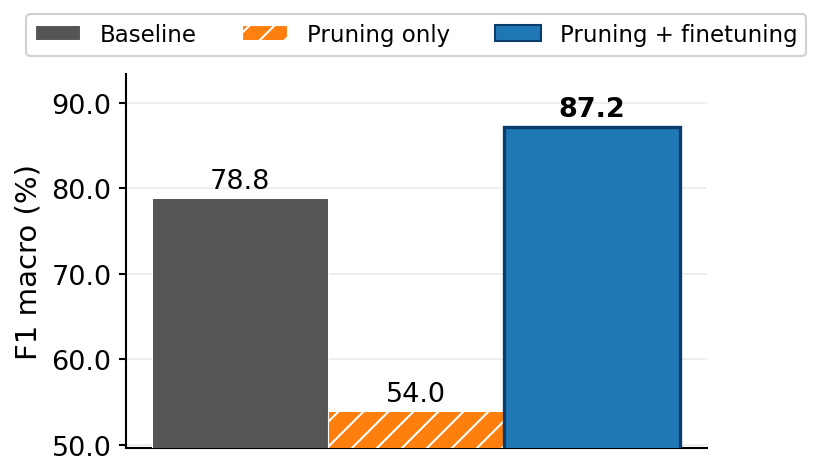

In [26]:
# ── Pruning F1 absolute — NCT-CRC-HE-100K ────────────────────────────────────
df_nct = pd.read_csv("results/pruning_comparison_NCT-CRC-HE-100K.csv")
# ── Pruning F1 absolute in percentuale — NCT-CRC-HE-100K ─────────────────────
CONDITIONS   = ["Baseline", "Pruning only", "Pruning +\nfinetuning"]
F1_COLS      = ["baseline_f1", "pruned_f1", "finetuned_f1"]
COLORS       = [C_DARK, C_ORANGE, C_OURS]
HATCHES      = ["", "//", ""]

datasets_nct = df_nct["dataset"].tolist()
n_ds     = len(datasets_nct)
n_cond   = len(CONDITIONS)
x        = np.arange(n_ds)
width    = 0.22
offsets  = np.linspace(-(n_cond - 1) / 2, (n_cond - 1) / 2, n_cond) * width

fig, ax = plt.subplots(figsize=(5.5 + 2.0 * (n_ds - 1), 3.4))

for i, (col, cond, color, hatch) in enumerate(zip(F1_COLS, CONDITIONS, COLORS, HATCHES)):
    vals = df_nct[col].values * 100  # convertiamo in percentuale
    bars = ax.bar(
        x + offsets[i], vals, width,
        color=color, hatch=hatch,
        edgecolor="white", linewidth=0.5,
        zorder=3,
    )
    if color == C_OURS:
        for bar in bars:
            bar.set_edgecolor(C_EDGE)
            bar.set_linewidth(1.6)

    # Etichette sopra le barre in percentuale
    for bar, val in zip(bars, vals):
        fw = "bold" if color == C_OURS else "normal"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.1f}",  # valore senza %
            ha="center", va="bottom", fontsize=FONT - 1, fontweight=fw,
        )


ax.set_ylabel("F1 macro (%)", fontsize=FONT)

ymin = df_nct[F1_COLS].min().min() * 100 * 0.92
ymax = df_nct[F1_COLS].max().max() * 100 * 1.07
ax.set_ylim(ymin, ymax)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax.grid(axis="y", alpha=0.25, zorder=0)
ax.tick_params(axis="x", length=0)  # rimuove tutte le tacche sull'asse X

pruning_legend = [
    mpatches.Patch(facecolor=C_DARK,   edgecolor="white", hatch="",   label="Baseline"),
    mpatches.Patch(facecolor=C_ORANGE, edgecolor="white", hatch="//", label="Pruning only"),
    mpatches.Patch(facecolor=C_OURS,   edgecolor=C_EDGE,  hatch="",   label="Pruning + finetuning"),
]
ax.legend(
    handles=pruning_legend,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(pruning_legend),
    fontsize=FONT - 3,
    framealpha=0.9
)
ax.set_xticks([])          # rimuove i tick (numeri o etichette) sull’asse X
ax.tick_params(axis="x", length=0)  # rimuove le tacche

plt.tight_layout()
savepdf(fig, "pruning_f1_absolute_nctcrc_pct")
plt.show()